In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

Saving BlackFridaySales.csv to BlackFridaySales.csv


In [6]:
data = pd.read_csv("BlackFridaySales.csv")

In [7]:
data.shape

(550068, 12)

In [8]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [10]:
data.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,173638


# **EDA**

In [11]:
data['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


# **Gender**

> Add blockquote



<Axes: xlabel='Gender', ylabel='count'>

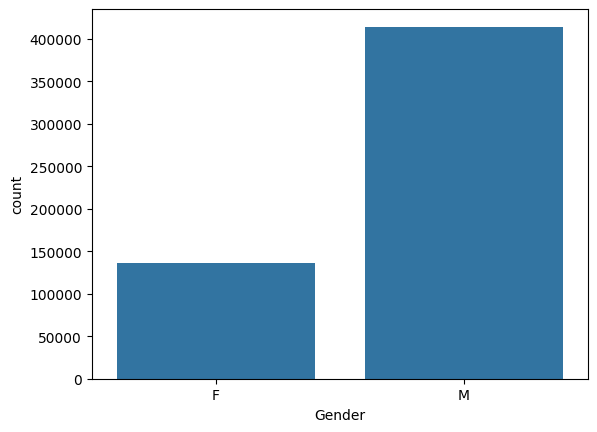

In [12]:
sns.countplot(x='Gender',data=data)

In [13]:
data.groupby("Gender")["Purchase"].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


<Axes: xlabel='Gender'>

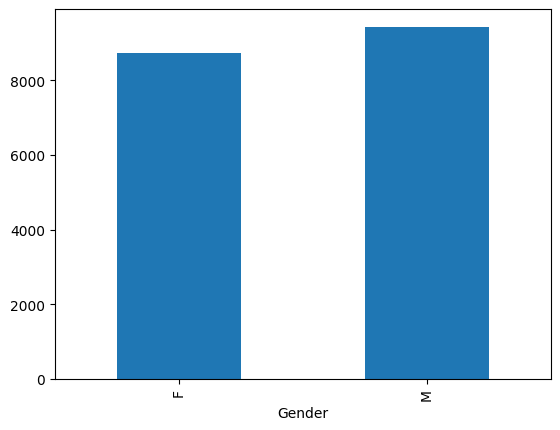

In [14]:
data.groupby("Gender")["Purchase"].mean().plot(kind="bar")

# **Age**

<Axes: xlabel='Age', ylabel='count'>

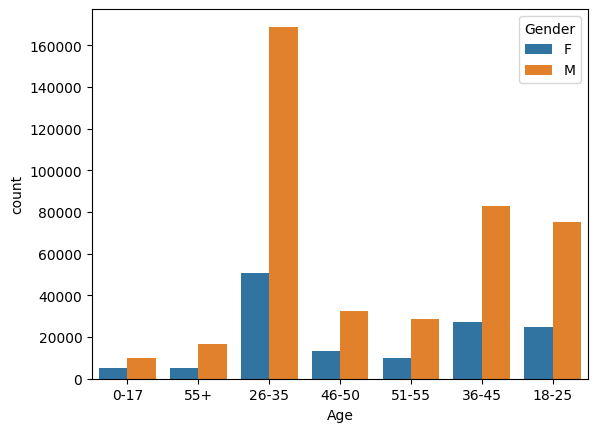

In [15]:
sns.countplot(x='Age',data=data,hue='Gender')

In [16]:
data.groupby("Age")["Purchase"].mean()

,Purchase
Age,
0-17,8933.464640
18-25,9169.663606
26-35,9252.690633
36-45,9331.350695
46-50,9208.625697
51-55,9534.808031
55+,9336.280459


<Axes: xlabel='Age'>

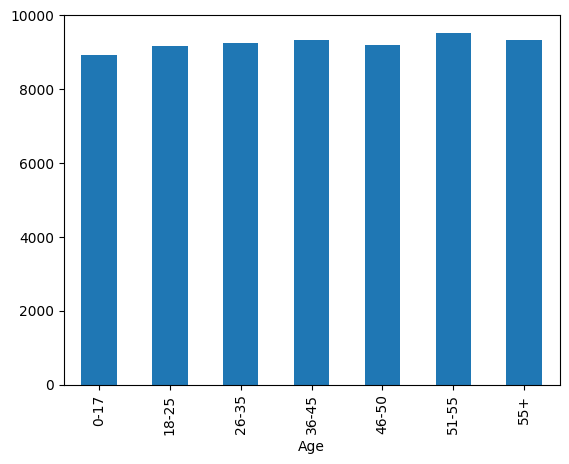

In [17]:
data.groupby("Age")["Purchase"].mean().plot(kind='bar')

<Axes: xlabel='Age'>

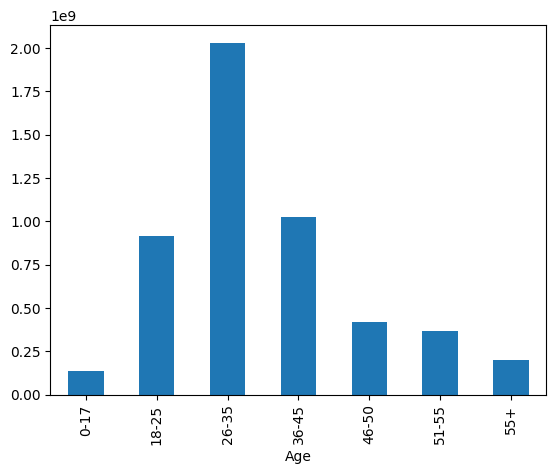

In [18]:
data.groupby("Age")["Purchase"].sum().plot(kind='bar')

# **Occupation**

<Axes: xlabel='Occupation', ylabel='count'>

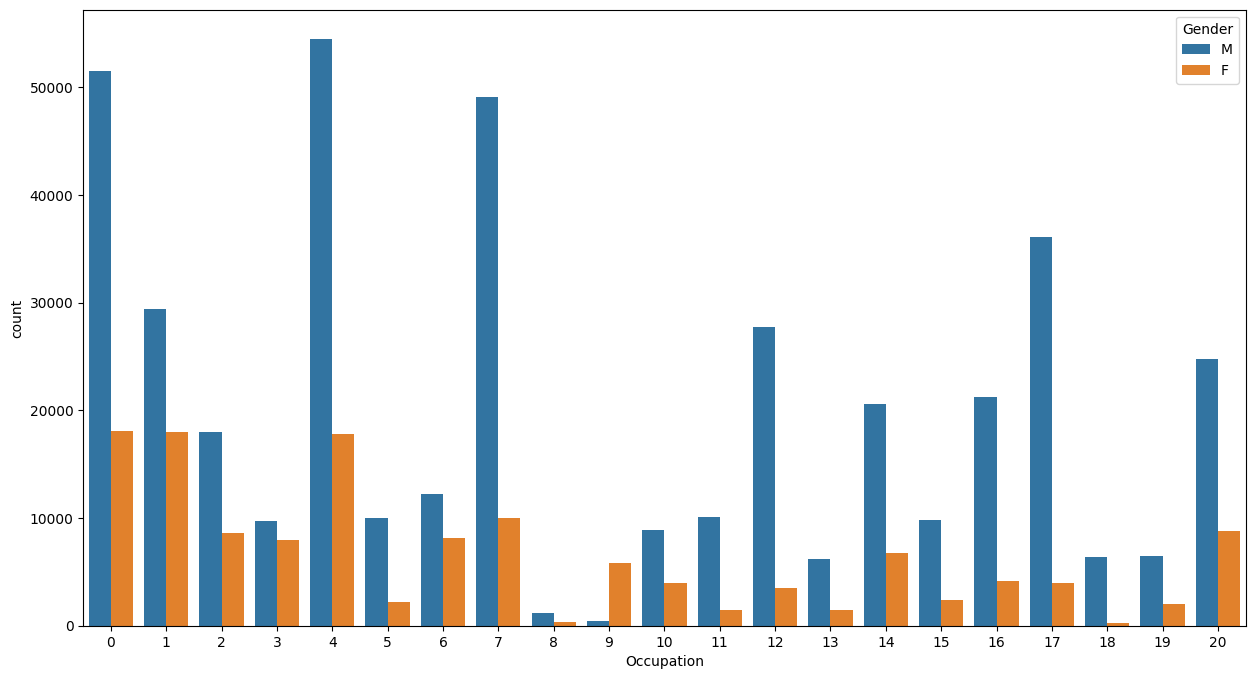

In [19]:
plt.figure(figsize=(15,8))
sns.countplot(x='Occupation',data=data,hue='Gender')

<Axes: xlabel='Occupation', ylabel='Purchase'>

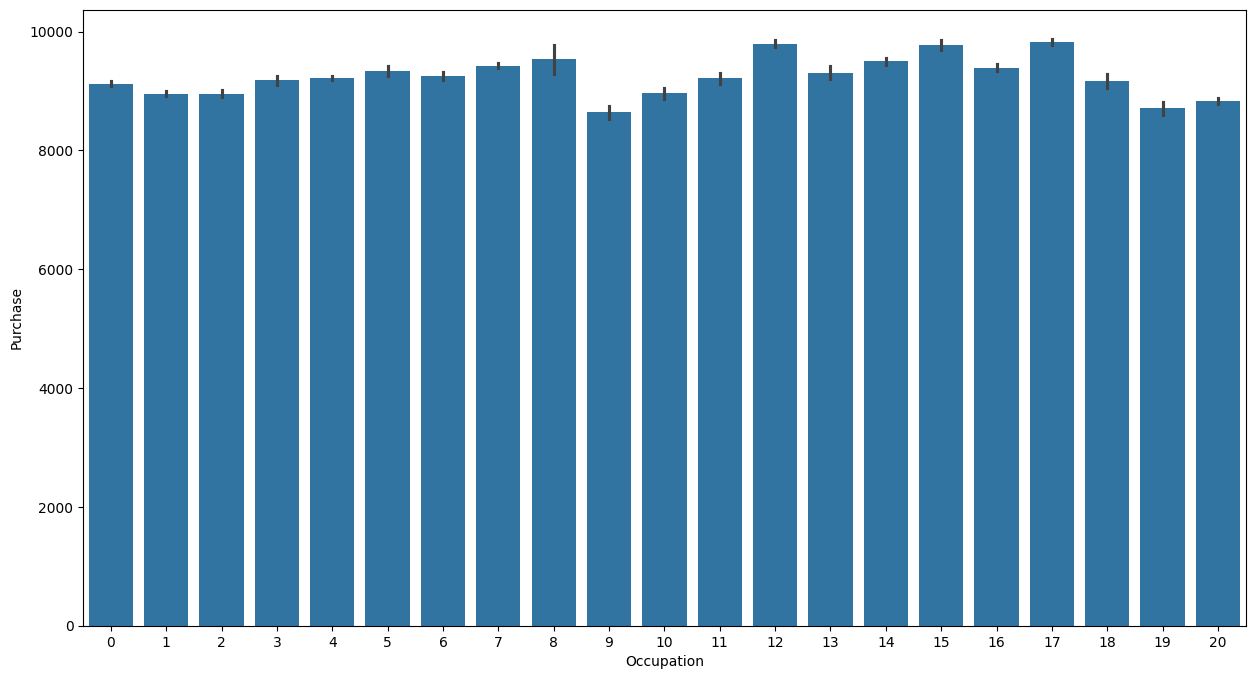

In [20]:
plt.figure(figsize=(15,8))
sns.barplot(x='Occupation',y='Purchase',data=data)

<Axes: xlabel='Occupation'>

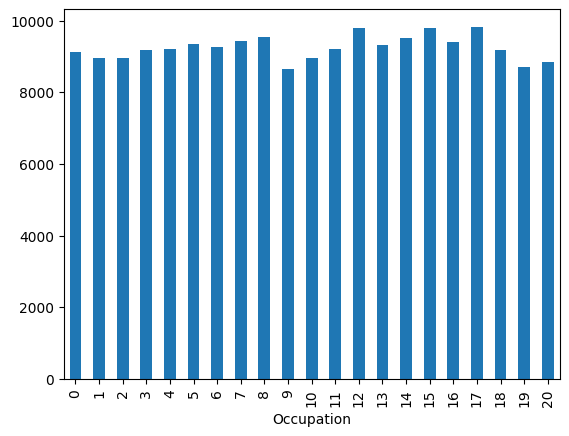

In [21]:
data.groupby("Occupation")["Purchase"].mean().plot(kind='bar')

# **City_Category**

<Axes: xlabel='City_Category', ylabel='count'>

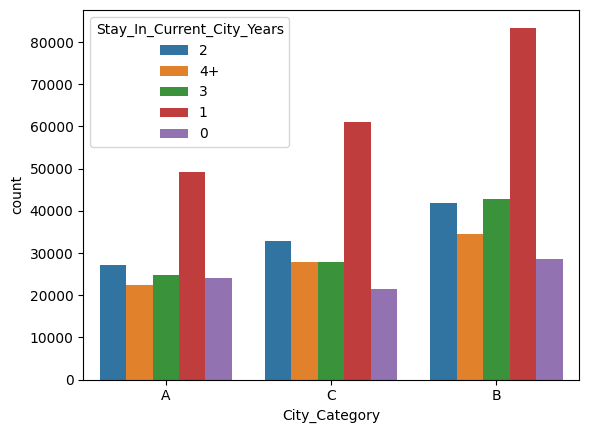

In [22]:
sns.countplot(x='City_Category',data=data,hue='Stay_In_Current_City_Years')

<Axes: xlabel='City_Category', ylabel='Purchase'>

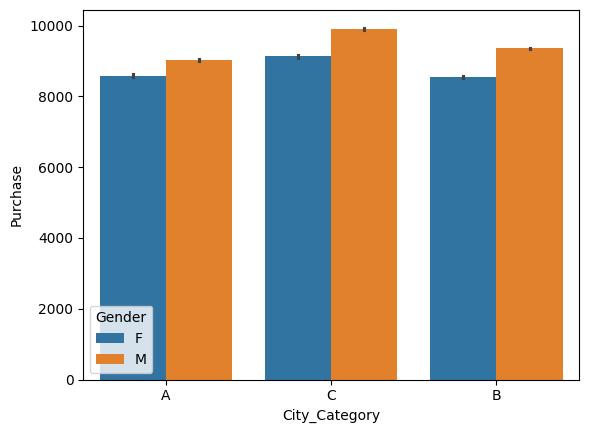

In [23]:
sns.barplot(x='City_Category',y='Purchase',data=data,hue='Gender')

<Axes: xlabel='City_Category'>

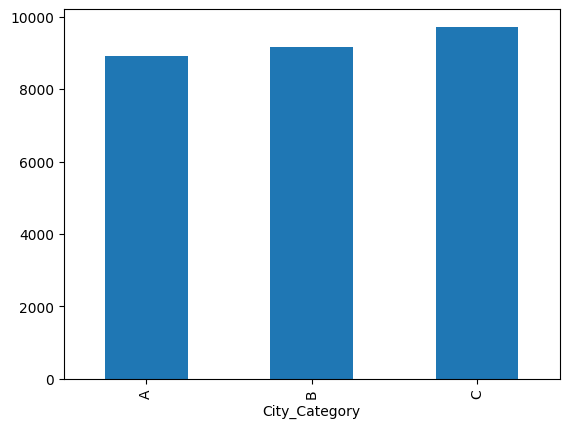

In [24]:
data.groupby("City_Category")["Purchase"].mean().plot(kind='bar')

# **Marital Status**

<Axes: xlabel='Marital_Status', ylabel='count'>

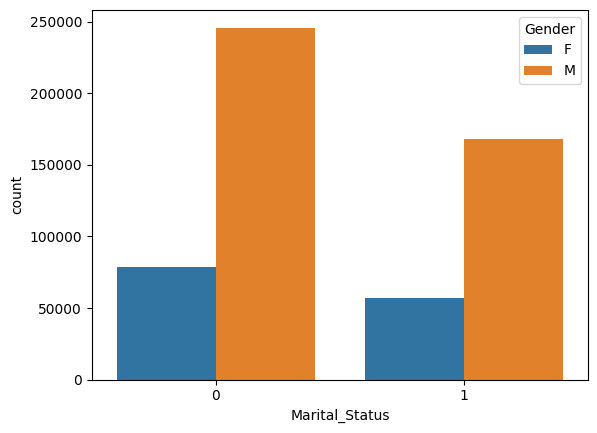

In [25]:
sns.countplot(x='Marital_Status',data=data,hue='Gender')

<Axes: xlabel='Marital_Status'>

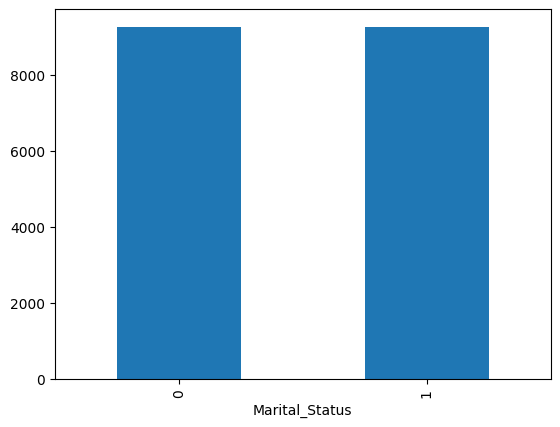

In [26]:
data.groupby("Marital_Status")["Purchase"].mean().plot(kind='bar')

# **Product_Category_1**


<Axes: xlabel='Product_Category_1', ylabel='count'>

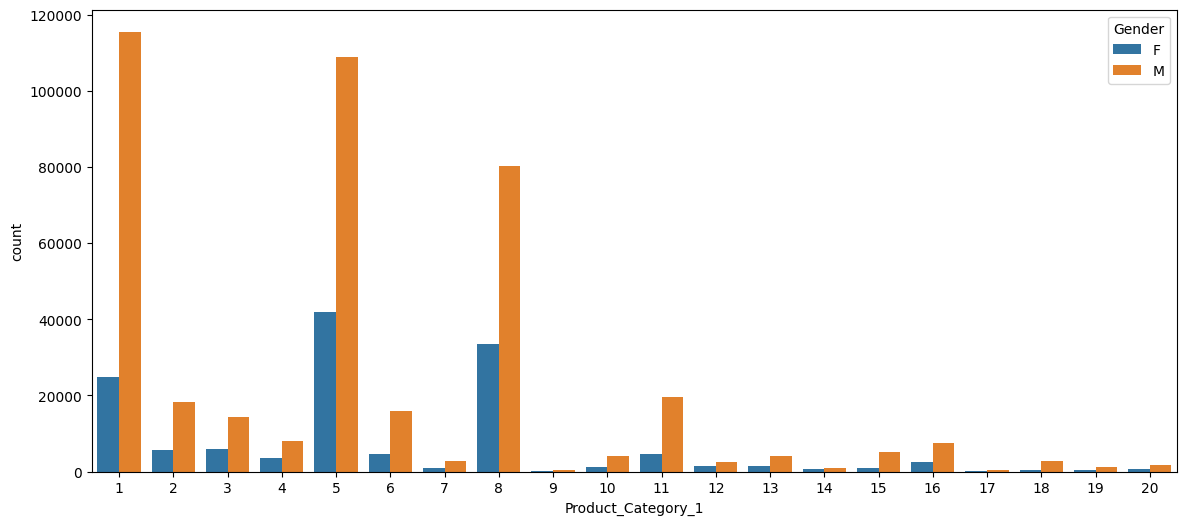

In [27]:
plt.figure(figsize=(14,6))

sns.countplot(x='Product_Category_1',data=data,hue='Gender')

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

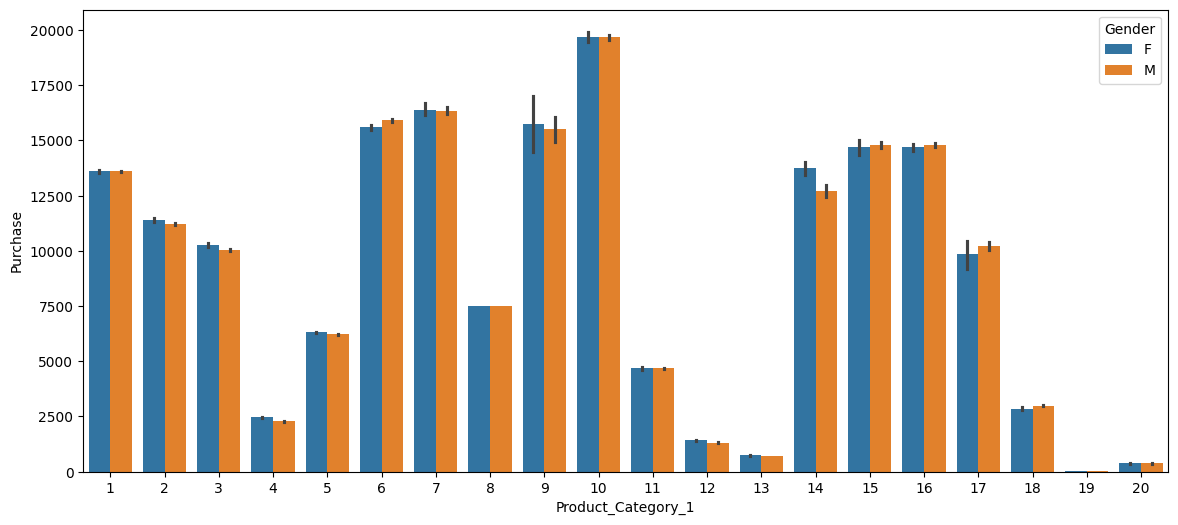

In [28]:
plt.figure(figsize=(14,6))
sns.barplot(x='Product_Category_1',y='Purchase',data=data,hue='Gender')

<Axes: xlabel='Product_Category_1'>

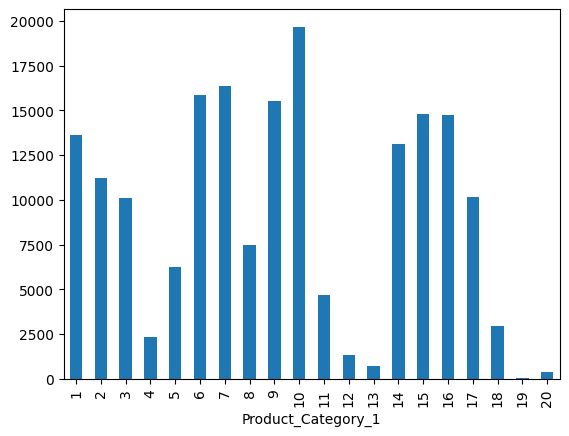

In [29]:
data.groupby("Product_Category_1")["Purchase"].mean().plot(kind='bar')

# **Product_Category_2**

<Axes: xlabel='Product_Category_2', ylabel='count'>

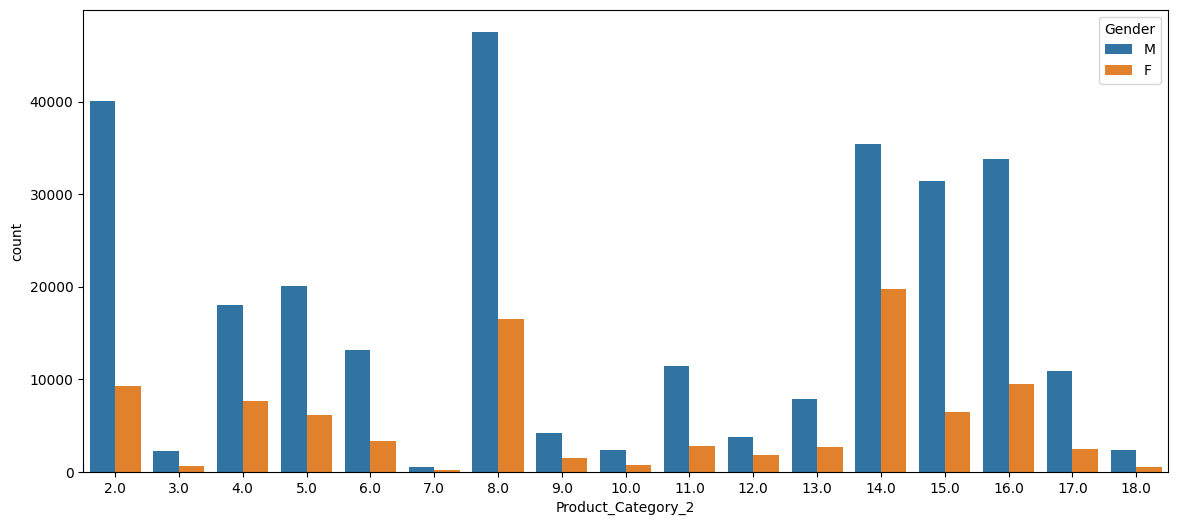

In [30]:
plt.figure(figsize=(14,6))
sns.countplot(x='Product_Category_2',data=data,hue='Gender')

<Axes: xlabel='Product_Category_2', ylabel='Purchase'>

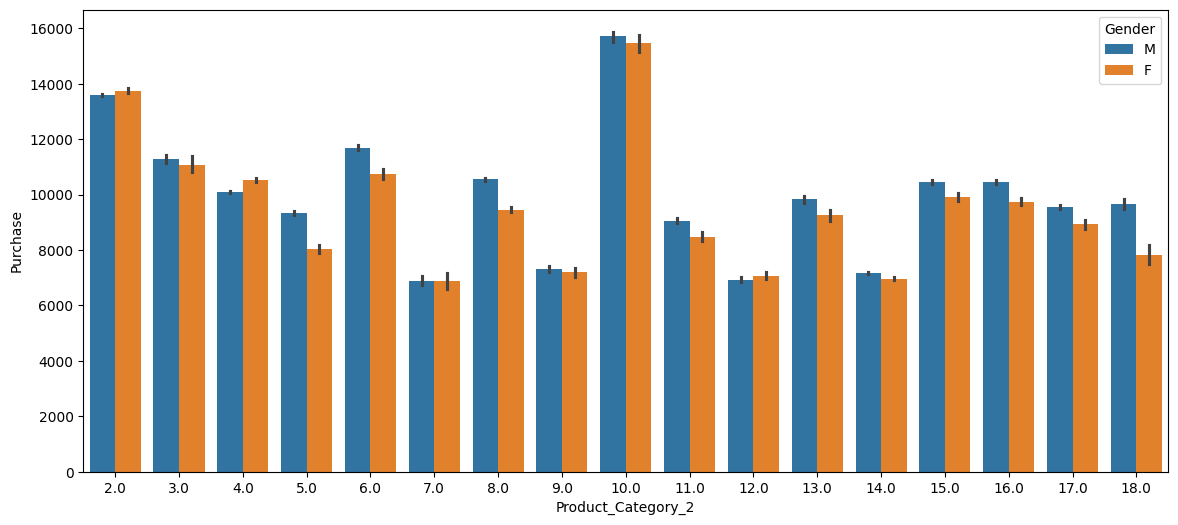

In [31]:
plt.figure(figsize=(14,6))
sns.barplot(x='Product_Category_2',y='Purchase',data=data,hue='Gender')

<Axes: xlabel='Product_Category_2'>

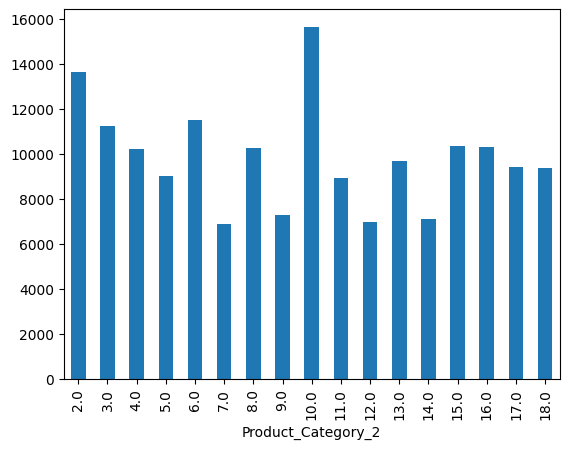

In [32]:
data.groupby("Product_Category_2")["Purchase"].mean().plot(kind='bar')

# **Product_Category_3**

<Axes: xlabel='Product_Category_3', ylabel='count'>

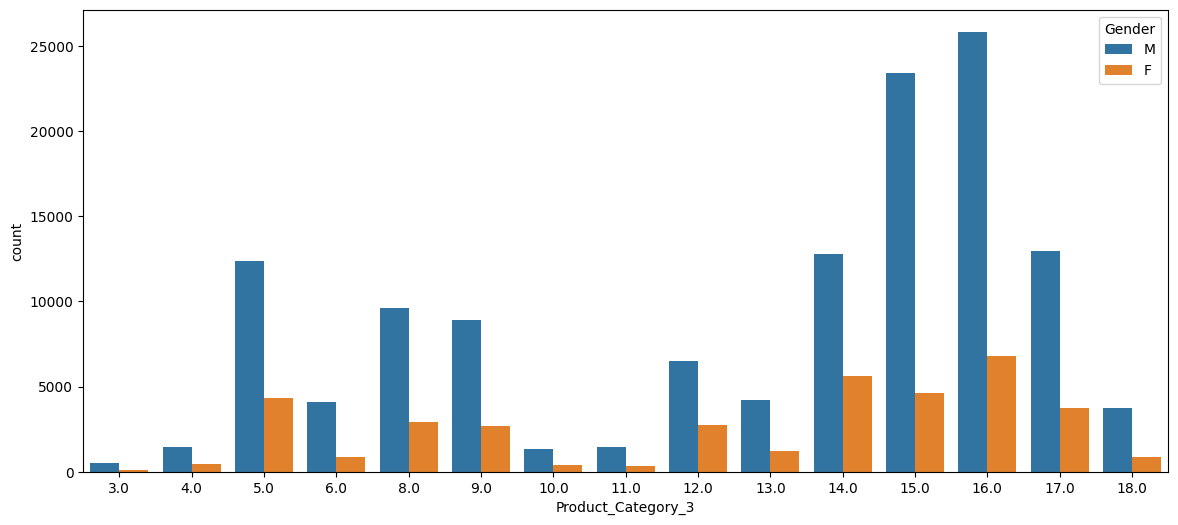

In [33]:
plt.figure(figsize=(14,6))
sns.countplot(x='Product_Category_3',data=data,hue='Gender')

<Axes: xlabel='Product_Category_3', ylabel='Purchase'>

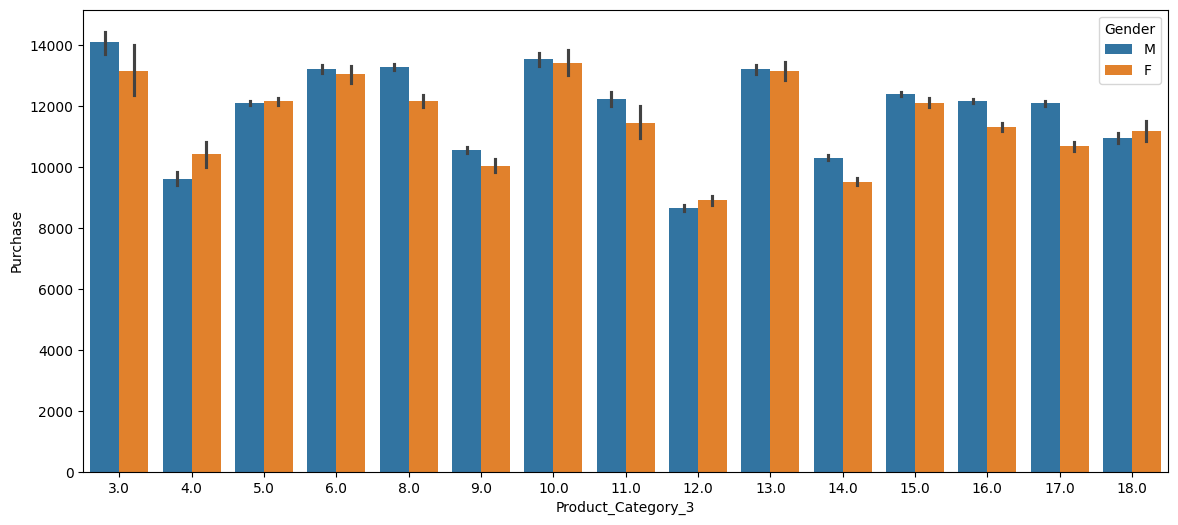

In [34]:
plt.figure(figsize=(14,6))
sns.barplot(x='Product_Category_3',y='Purchase',data=data,hue='Gender')

<Axes: xlabel='Product_Category_3'>

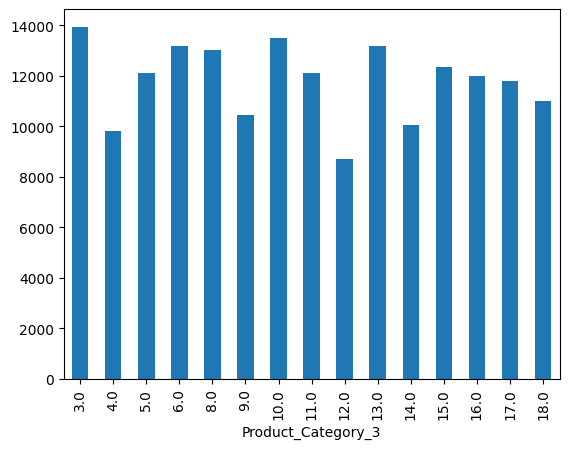

In [35]:
data.groupby("Product_Category_3")["Purchase"].mean().plot(kind='bar')

# **HeatMap**

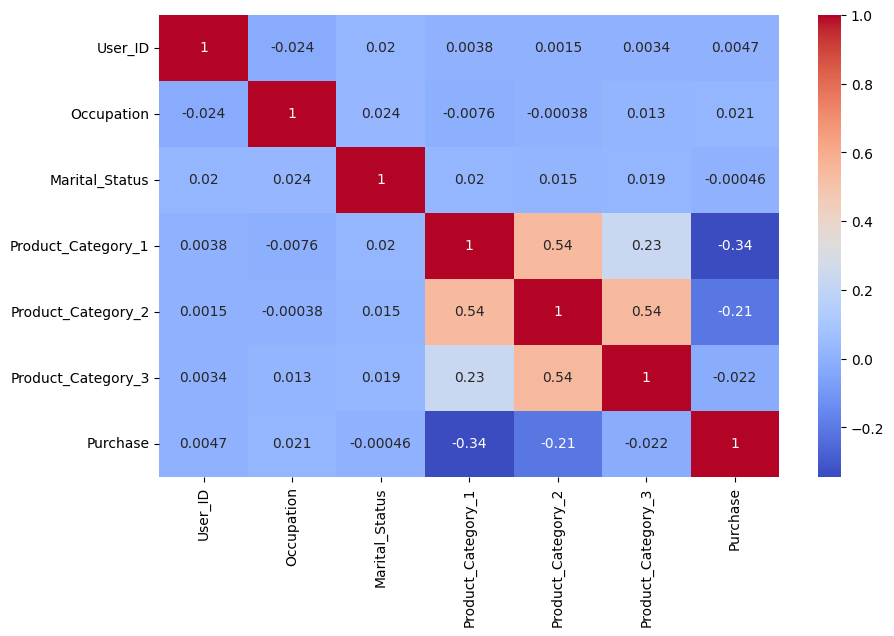

In [41]:
numeric_data = data.select_dtypes(include=['int64','float64'])
# Compute correlation
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [42]:
df = data.copy()

In [43]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].replace(to_replace="4+",value="4")

In [44]:
df = pd.get_dummies(df, columns=['Stay_In_Current_City_Years'])

In [45]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Stay_In_Current_City_Years_0,Stay_In_Current_City_Years_1,Stay_In_Current_City_Years_2,Stay_In_Current_City_Years_3,Stay_In_Current_City_Years_4
0,1000001,P00069042,F,0-17,10,A,0,3,NaN,NaN,8370,False,False,True,False,False
1,1000001,P00248942,F,0-17,10,A,0,1,6.0,14.0,15200,False,False,True,False,False
2,1000001,P00087842,F,0-17,10,A,0,12,NaN,NaN,1422,False,False,True,False,False
3,1000001,P00085442,F,0-17,10,A,0,12,14.0,NaN,1057,False,False,True,False,False
4,1000002,P00285442,M,55+,16,C,0,8,NaN,NaN,7969,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,20,NaN,NaN,368,False,True,False,False,False
550064,1006035,P00375436,F,26-35,1,C,0,20,NaN,NaN,371,False,False,False,True,False
550065,1006036,P00375436,F,26-35,15,B,1,20,NaN,NaN,137,False,False,False,False,True
550066,1006038,P00375436,F,55+,1,C,0,20,NaN,NaN,365,False,False,True,False,False


# **Encoding Categorical variables**

In [46]:
from sklearn.preprocessing import LabelEncoder
lr = LabelEncoder()

In [47]:
df['Gender'] = lr.fit_transform(df['Gender'])
df['Age'] = lr.fit_transform(df['Age'])
df['City_Category'] = lr.fit_transform(df['City_Category'])

In [48]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Stay_In_Current_City_Years_0,Stay_In_Current_City_Years_1,Stay_In_Current_City_Years_2,Stay_In_Current_City_Years_3,Stay_In_Current_City_Years_4
0,1000001,P00069042,0,0,10,0,0,3,NaN,NaN,8370,False,False,True,False,False
1,1000001,P00248942,0,0,10,0,0,1,6.0,14.0,15200,False,False,True,False,False
2,1000001,P00087842,0,0,10,0,0,12,NaN,NaN,1422,False,False,True,False,False
3,1000001,P00085442,0,0,10,0,0,12,14.0,NaN,1057,False,False,True,False,False
4,1000002,P00285442,1,6,16,2,0,8,NaN,NaN,7969,False,False,False,False,True


In [49]:
df['Product_Category_2'] =df['Product_Category_2'].fillna(0).astype('int64')
df['Product_Category_3'] =df['Product_Category_3'].fillna(0).astype('int64')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   User_ID                       550068 non-null  int64 
 1   Product_ID                    550068 non-null  object
 2   Gender                        550068 non-null  int64 
 3   Age                           550068 non-null  int64 
 4   Occupation                    550068 non-null  int64 
 5   City_Category                 550068 non-null  int64 
 6   Marital_Status                550068 non-null  int64 
 7   Product_Category_1            550068 non-null  int64 
 8   Product_Category_2            550068 non-null  int64 
 9   Product_Category_3            550068 non-null  int64 
 10  Purchase                      550068 non-null  int64 
 11  Stay_In_Current_City_Years_0  550068 non-null  bool  
 12  Stay_In_Current_City_Years_1  550068 non-null  bool  
 13 

In [51]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,0
Product_Category_3,0


# **Dropping the irrelavant columns**

In [52]:
df = df.drop(["User_ID","Product_ID"],axis=1)

# **Splitting data into independent and dependent variables**

In [53]:
X = df.drop("Purchase",axis=1)

In [54]:
y=df['Purchase']

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

# **Modeling**

# **linear Regression**

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [58]:
lr.intercept_

np.float64(9536.400764131593)

In [59]:
lr.coef_

array([ 465.82318446,  112.36643445,    5.05508596,  314.06766138,
        -58.23217776, -348.4514785 ,   12.98415047,  143.49190467,
        -20.83796687,    5.4676518 ,   17.68367185,   -3.96751734,
          1.65416056])

In [60]:
y_pred = lr.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [62]:
mean_absolute_error(y_test, y_pred)

3532.069226165843

In [63]:
mean_squared_error(y_test, y_pred)

21397853.26940751

In [64]:
r2_score(y_test, y_pred)

0.15192944521481688

In [65]:
from math import sqrt
print("RMSE of Linear Regression Model is ",sqrt(mean_squared_error(y_test, y_pred)))

RMSE of Linear Regression Model is  4625.781368526566


# **Decision Tree Regressor**

In [66]:
from sklearn.tree import DecisionTreeRegressor

# create a regressor object
regressor = DecisionTreeRegressor(random_state = 0)

In [67]:
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=0)

In [68]:
dt_y_pred = regressor.predict(X_test)

In [69]:
mean_absolute_error(y_test, dt_y_pred)

2372.0357559134654

In [70]:
mean_squared_error(y_test, dt_y_pred)

11300579.466797074

In [71]:
r2_score(y_test, dt_y_pred)

0.5521191505924365

In [72]:
from math import sqrt
print("RMSE of Linear Regression Model is ",sqrt(mean_squared_error(y_test, dt_y_pred)))

RMSE of Linear Regression Model is  3361.633452177241


# **Random Forest Regressor**

In [73]:
from sklearn.ensemble import RandomForestRegressor

# create a regressor object
RFregressor = RandomForestRegressor(random_state = 0)

In [74]:
RFregressor.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [75]:
rf_y_pred = RFregressor.predict(X_test)

In [76]:
mean_absolute_error(y_test, rf_y_pred)

2222.049109204734

In [77]:
mean_squared_error(y_test, rf_y_pred)

9310769.87311957

In [78]:
r2_score(y_test, rf_y_pred)

0.6309821516972987

In [79]:
from math import sqrt
print("RMSE of Linear Regression Model is ",sqrt(mean_squared_error(y_test, rf_y_pred)))

RMSE of Linear Regression Model is  3051.35541573242


# **XG Boost Regressor**

In [80]:
from xgboost.sklearn import XGBRegressor

In [81]:
xgb_reg = XGBRegressor(learning_rate=1.0, max_depth=6, min_child_weight=40, seed=0)

xgb_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=1.0, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=40, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [82]:
xgb_y_pred = xgb_reg.predict(X_test)

In [83]:
mean_absolute_error(y_test, xgb_y_pred)

2141.713623046875

In [84]:
mean_squared_error(y_test, xgb_y_pred)

8241185.0

In [85]:
r2_score(y_test, xgb_y_pred)

0.6733734607696533

In [86]:
from math import sqrt
print("RMSE of Linear Regression Model is ",sqrt(mean_squared_error(y_test, xgb_y_pred)))

RMSE of Linear Regression Model is  2870.746418616594


**The ML algorithm that perform the best was XGBoost Regressor Model with RMSE = 2870**